In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"

In [3]:
# !wget $data

In [4]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')

In [5]:
df

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,2005,USA,Gasoline,All-wheel drive,4,2470,6,271.0,4690,18.9,27.4
9996,1993,Asia,Gasoline,All-wheel drive,2,2300,6,244.0,4370,19.0,30.0
9997,2014,USA,Gasoline,All-wheel drive,3,2480,6,267.0,4590,18.4,28.1
9998,2004,USA,Hybrid,Rear-wheel drive,5,2180,6,270.0,4450,20.9,32.2


In [6]:
for col in df.columns:
    print(col)
    print(df[col].nunique())
    print(df[col].unique()[:5])
    print()

model_year
50
[2006 2008 1996 1989 1994]

origin
3
<StringArray>
['Europe', 'Asia', 'USA']
Length: 3, dtype: str

fuel_type
3
<StringArray>
['Gasoline', 'Diesel', 'Hybrid']
Length: 3, dtype: str

drivetrain
3
<StringArray>
['Front-wheel drive', 'Rear-wheel drive', 'All-wheel drive']
Length: 3, dtype: str

num_doors
4
[4 5 3 2]

engine_displacement
127
[2180 2390 2320 2130 2580]

num_cylinders
5
[6 7 5 8 4]

horsepower
153
[243. 272. 267. 258. 304.]

vehicle_weight
176
[3870 4210 4240 4490 4510]

acceleration
93
[ nan 17.3 18.7 17.5 18.8]

fuel_efficiency_mpg
188
[31.9 31.3 27.5 28.5 31. ]



In [7]:
df.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

In [8]:
df.model_year.min()

np.int64(1975)

In [9]:
df = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

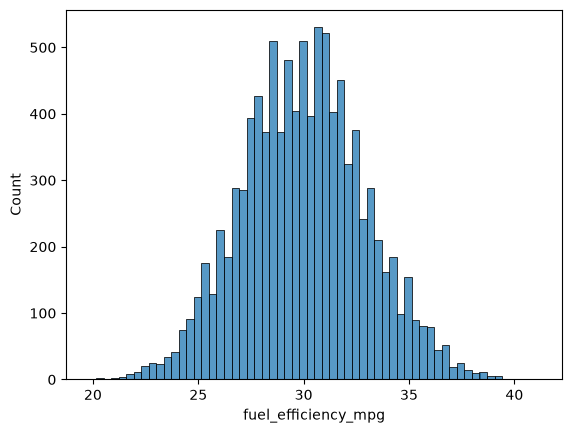

In [10]:
sns.histplot(df.fuel_efficiency_mpg)

In [11]:
df.fuel_efficiency_mpg.mode().iloc[0]

np.float64(30.2)

In [12]:
df.fuel_efficiency_mpg.median()

np.float64(30.0)

In [13]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [14]:
df.horsepower.median()

np.float64(254.0)

In [15]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = int(n - n_val - n_test)

In [16]:
n, n_val, n_test, n_train

(10000, 2000, 2000, 6000)

In [17]:
np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)
idx

array([6252, 4684, 1731, ..., 5390,  860, 7270], shape=(10000,))

In [18]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [19]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [20]:
df_val

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2240,265.0,3990,2004,30.4
1,2390,259.0,4770,2019,32.8
2,2360,265.0,4320,2018,27.8
3,2430,279.0,4430,2008,28.6
4,2220,249.0,4030,1999,31.1
...,...,...,...,...,...
1995,1980,229.0,4140,2020,30.3
1996,2590,263.0,4630,1989,28.7
1997,2390,264.0,4550,2017,30.6
1998,2330,244.0,4440,2014,31.0


In [21]:
mean = df_train.horsepower.mean()
mean

np.float64(254.46338337605272)

In [35]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    w0 = w_full[0]
    w = w_full[1:]
    return w0, w

In [23]:
y_train = df_train.fuel_efficiency_mpg.values
y_train

array([32.5, 29.1, 34.1, ..., 27.7, 31.6, 28. ], shape=(6000,))

In [24]:
y_val = df_val.fuel_efficiency_mpg.values
y_val

array([30.4, 32.8, 27.8, ..., 30.6, 31. , 30.8], shape=(2000,))

In [25]:
y_test = df_test.fuel_efficiency_mpg.values
y_test

array([27.8, 37.3, 33.1, ..., 30.1, 30.5, 34.9], shape=(2000,))

In [26]:
del df_train['fuel_efficiency_mpg']

In [27]:
df_train

,engine_displacement,horsepower,vehicle_weight,model_year
0,1900,239.0,3790,2015
1,2000,224.0,4380,1992
2,2330,286.0,4090,2022
3,2300,NaN,4150,1997
4,2340,269.0,4400,2001
...,...,...,...,...
5995,2280,242.0,4590,2018
5996,2300,NaN,4240,1984
5997,2240,255.0,4190,1989
5998,2430,254.0,4280,2020


In [28]:
del df_val['fuel_efficiency_mpg']

In [29]:
del df_test['fuel_efficiency_mpg']

In [30]:
y_test

array([27.8, 37.3, 33.1, ..., 30.1, 30.5, 34.9], shape=(2000,))

In [31]:
df_train

,engine_displacement,horsepower,vehicle_weight,model_year
0,1900,239.0,3790,2015
1,2000,224.0,4380,1992
2,2330,286.0,4090,2022
3,2300,NaN,4150,1997
4,2340,269.0,4400,2001
...,...,...,...,...
5995,2280,242.0,4590,2018
5996,2300,NaN,4240,1984
5997,2240,255.0,4190,1989
5998,2430,254.0,4280,2020


In [32]:
def prepare_X1(df):
    df_num = df.fillna(mean)
    X = df_num.values

    return X

In [33]:
def prepare_X2(df):
    df_num = df.fillna(0)
    X = df_num.values

    return X

In [34]:
X_train = prepare_X1(df_train)
X_train

array([[1900.,  239., 3790., 2015.],
       [2000.,  224., 4380., 1992.],
       [2330.,  286., 4090., 2022.],
       ...,
       [2240.,  255., 4190., 1989.],
       [2430.,  254., 4280., 2020.],
       [2390.,  266., 4220., 1996.]], shape=(6000, 4))

In [37]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [41]:
X_train = prepare_X1(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X1(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred).round(3)

np.float64(2.202)

In [42]:
X_train = prepare_X2(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X2(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred).round(3)

np.float64(2.205)

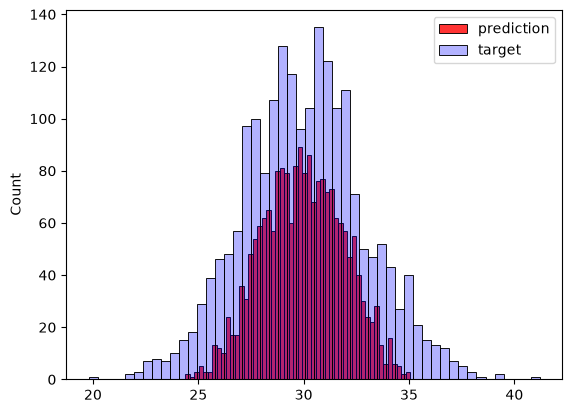

In [49]:
sns.histplot(y_pred, color='red', alpha=0.8, label='prediction', bins=50)
sns.histplot(y_val, color='blue', alpha=0.3, label='target', bins=50)
plt.legend()

In [59]:
def train_linear_regression_reg(X, y, r=0.01):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    w0 = w_full[0]
    w = w_full[1:]
    return w0, w

In [61]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X2(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    
    X_val = prepare_X2(df_val)
    y_pred = w0 + X_val.dot(w)
    
    score = rmse(y_val, y_pred).round(4)
    print(r, score)

0 2.2053
0.01 2.2058
0.1 2.2241
1 2.3492
5 2.4094
10 2.4195
100 2.4292


In [66]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = int(n - n_val - n_test)

df_train = {}
df_val = {}
df_test = {}
y_train = {}
y_val = {}
y_test = {}
for i in range(10):
    np.random.seed(i)
    idx = np.arange(n)
    np.random.shuffle(idx)
    idx
    
    df_train[i] = df.iloc[idx[:n_train]]
    df_val[i] = df.iloc[idx[n_train:n_train+n_val]]
    df_test[i] = df.iloc[idx[n_train+n_val:]]

    df_train[i] = df_train[i].reset_index(drop=True)
    df_val[i] = df_val[i].reset_index(drop=True)
    df_test[i] = df_test[i].reset_index(drop=True)

    y_train[i] = df_train[i].fuel_efficiency_mpg.values
    y_val[i] = df_val[i].fuel_efficiency_mpg.values
    y_test[i] = df_test[i].fuel_efficiency_mpg.values

    del df_train[i]['fuel_efficiency_mpg']
    del df_val[i]['fuel_efficiency_mpg']
    del df_test[i]['fuel_efficiency_mpg']

In [82]:
df_train[1]

,engine_displacement,horsepower,vehicle_weight,model_year
0,2230,247.0,4020,1978
1,2120,235.0,4100,1986
2,2130,244.0,4410,1996
3,1900,209.0,3590,1997
4,2210,229.0,4270,1992
...,...,...,...,...
5995,2580,297.0,4420,2019
5996,2100,232.0,4540,1982
5997,2360,NaN,4540,2000
5998,2570,287.0,4490,2005


In [83]:
X_train = {}
X_val = {}
for i in range(10):
    X_train[i] = prepare_X2(df_train[i])
    X_val[i] = prepare_X2(df_val[i])

In [84]:
scores = []
for i in range(10):
    w0, w = train_linear_regression(X_train[i], y_train[i])

    y_pred = w0 + X_val[i].dot(w)
    score = rmse(y_val[i], y_pred)
    scores.append(score)

In [85]:
scores

[np.float64(2.2392041430461465),
 np.float64(2.2021128210838907),
 np.float64(2.163419778753095),
 np.float64(2.2043588768539144),
 np.float64(2.2018800943312926),
 np.float64(2.2457851509084974),
 np.float64(2.269721207952404),
 np.float64(2.190794599933433),
 np.float64(2.2166112016864443),
 np.float64(2.207036592817851)]

In [87]:
np.std(scores).round(3)

np.float64(0.029)

In [88]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = int(n - n_val - n_test)

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)
idx

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [90]:
df_full_train = pd.concat([df_train, df_val])

In [94]:
df_full_train.reset_index(drop=True)

,engine_displacement,horsepower,vehicle_weight,model_year
0,2320,246.0,4100,2014
1,2230,252.0,4250,1998
2,2700,276.0,4490,2008
3,2220,269.0,4060,2004
4,2370,NaN,4690,1979
...,...,...,...,...
7995,2690,324.0,4510,2023
7996,1920,190.0,4000,1998
7997,1800,225.0,3980,1994
7998,1970,232.0,3560,2009


In [99]:
y_full_train = np.concatenate([y_train, y_val])
y_full_train

array([32.5, 33.2, 32.4, ..., 29.1, 32.2, 35.6], shape=(8000,))

In [102]:
X_full_train = prepare_X2(df_full_train)
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

X_test = prepare_X2(df_test)
y_pred = w0 + X_test.dot(w)

rmse(y_test, y_pred).round(3)

np.float64(2.236)